In [15]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

In [16]:
_path1 = 'C:\\Users\\86994\\Desktop\\12pre2.png'
image = cv2.imread(_path1)
print(image.shape)

(1057, 634, 3)


In [17]:
_path2 = 'E:\\dataset\\tok\\JPEGImages\\12.png'
image_src = cv2.imread(_path2)
print(image.shape)

(1057, 634, 3)


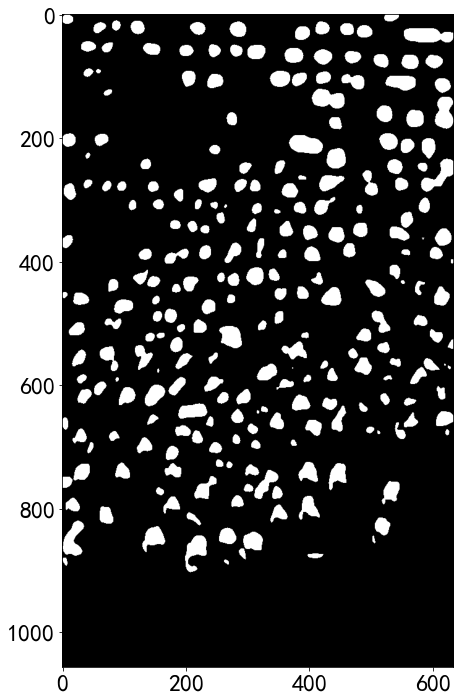

In [18]:
img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(9,12))
plt.imshow(img_gray, cmap='gray')

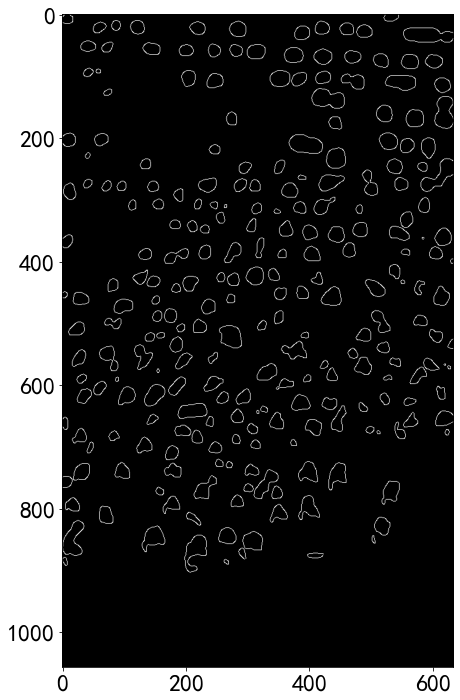

In [19]:
_canny_gray = cv2.Canny(img_gray, 20,35)
plt.figure(figsize=(9,12))
plt.imshow(_canny_gray, cmap='gray')

In [20]:
#找轮廓并发现最大轮廓
contours, hierarchy	= cv2.findContours(_canny_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

contours_size = np.array([cv2.arcLength(s,closed=True) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓，按t增加索引

In [21]:
contours_hull = [cv2.convexHull(cont) for cont in contours]

In [22]:
# 求面积
contours_area = [cv2.contourArea(contour) for contour in contours]
contours_area = np.array(contours_area)

In [23]:
_all_areas = np.sum(contours_area)
print(_all_areas)
print(_all_areas/(image.shape[0]*image.shape[1]))
print(np.max(contours_area) ,np.argmax(contours_area))
print(np.min(contours_area) ,np.argmin(contours_area))

82467.5
0.12306047411130244
1275.0 201
0.5 140


In [24]:
sort_index_area = np.argsort(-contours_area) #返回从大到小的索引,降序排列

In [25]:
print(contours_area[sort_index_area[-20]])

18.0


In [26]:
import matplotlib
# 预设字体格式，并传给rc方法
font = {'family': 'SimHei', "size": 24}
matplotlib.rc('font', **font)  # 一次定义终身使用

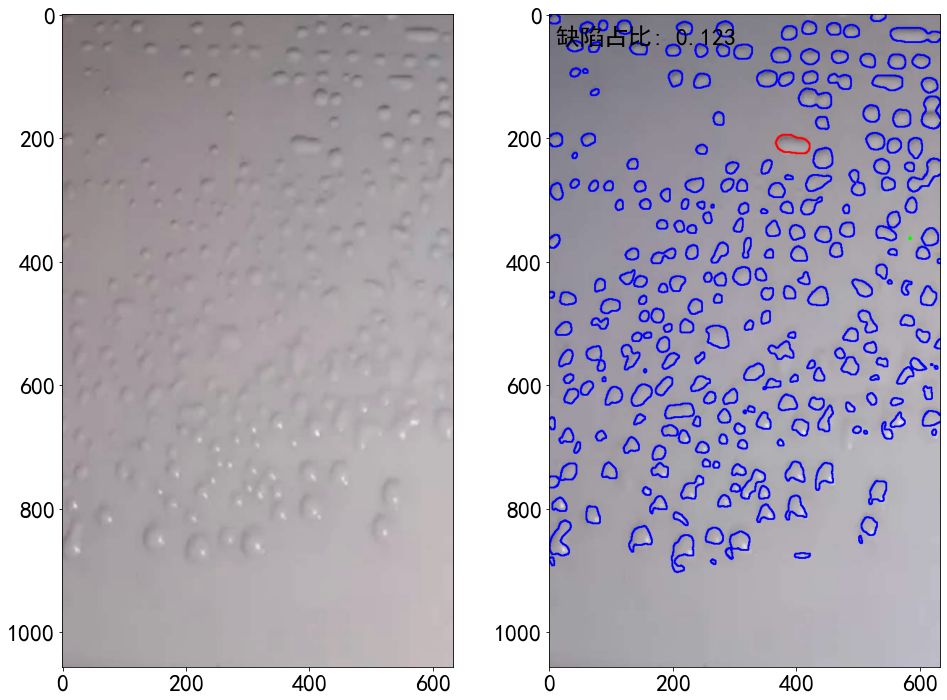

In [27]:
plt.figure(figsize=(16,12))
plt.subplot(1,2,1)
plt.imshow(image_src)
plt.subplot(1,2,2)
src_img = image_src.copy()
for _i in range(len(contours)):
    color = (255,0,0)
    if _i == sort_index_area[0]:
        color = (0,0,255)
    if _i == sort_index[-5]:
        color = (0,255, 0)
    cv2.drawContours(src_img, contours, _i, color, thickness=2) #画原轮廓，绿色
plt.text(10, 50, "缺陷占比: {}".format(str(_all_areas/(image.shape[0]*image.shape[1]))[:5]))
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.show()